In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy             as np
import pandas            as pd
import tables            as tb
import matplotlib.pyplot as plt
import seaborn as sns
import modules_TFM as mod
import random as rd

from scipy.optimize import curve_fit
from scipy.stats import binned_statistic_2d
from scipy.stats import binned_statistic

In [67]:
full_data=pd.read_hdf('C:/Users/pablo/OneDrive - Universidade de Santiago de Compostela/Máster/TFM/ldc1_merged.h5')
real_data=full_data[(full_data.DT>0) & (full_data.DT<1300) & (full_data.S1e>5)]

### Histograma de los datos sin el cátodo y s1 de más de 5 pes

(5.0, 45.0)

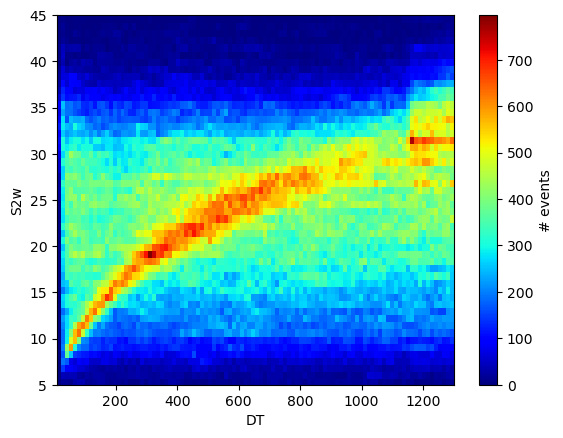

In [69]:
plt.hist2d(real_data.DT,real_data.S2w,bins=100,cmap='jet');
plt.colorbar(label='# events')
plt.xlabel('DT')
plt.ylabel('S2w')
plt.ylim(5,45)

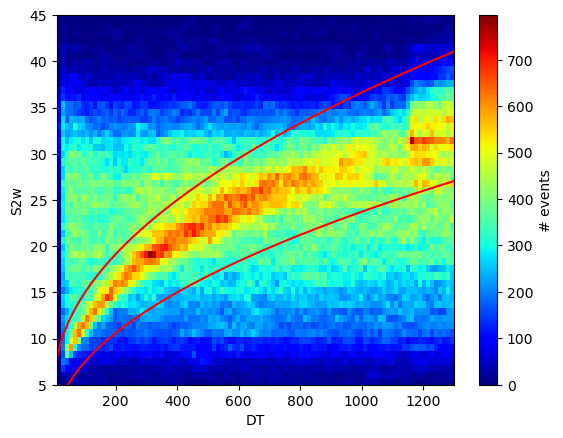

In [70]:
f= lambda x,a,b: a+b*x**0.5
f1 = lambda x: f(x,5,1)
f2 = lambda x: f(x,0,.75)

plt.hist2d(real_data.DT,real_data.S2w,bins=100,cmap='jet');
plt.colorbar(label='# events')
plt.xlabel('DT')
plt.ylabel('S2w')
plt.ylim(5,45)

x=np.linspace(0, max(real_data.DT),len(real_data.S2w))
plt.plot(x,f1(x), color='red')
plt.plot(x,f2(x), color='red')

In [71]:
def recompute_npeaks(df):
    events= df.groupby('event')
    ns1= events.s1_peak.nunique().values
    ns2= events.s2_peak.nunique().values
    n = events.s1_peak.count ().values
    df.loc[:, 'nS1'] = np.repeat(ns1,n) 
    df.loc[:, 'ns2']= np.repeat(ns2,n)
    return df

In [72]:
dst_in_recomputed=recompute_npeaks(real_data)

DT_raw=dst_in_recomputed.DT
s2w_raw=dst_in_recomputed.S2w

mask=(s2w_raw<f1(DT_raw))&(s2w_raw>f2(DT_raw))
inverse_mask=~mask

dst_in=dst_in_recomputed[mask]

DT_in=dst_in.DT
s2w_in=dst_in.S2w

dst_out=dst_in_recomputed[inverse_mask & (DT_raw>0)]

DT_out =dst_out.DT
s2w_out=dst_out.S2w

C:\Users\pablo\AppData\Local\Temp\ipykernel_15004\398798807.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'ns2']= np.repeat(ns2,n)


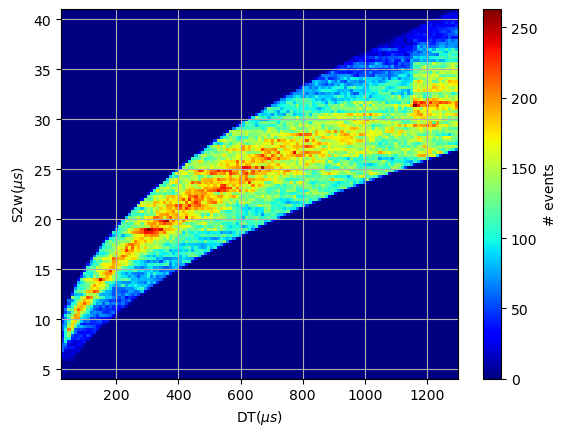

In [73]:
d2hist=plt.hist2d(DT_in, s2w_in, bins=125, cmap='jet')
plt.colorbar(label='# events')
plt.xlabel(r'DT($\mu s$)')
plt.ylabel(r'S2w($\mu s$)')
plt.grid()

### S1 vs DT inside the window.

Estudio los datos de S1 dentro del corte, impongo que estén lejos del cátodo, que la señal sea mayor de 5 pes y que estén en el corte.

### 1. S1h vs DT

Text(0.5, 1.0, 'Number of events of a S1h given')

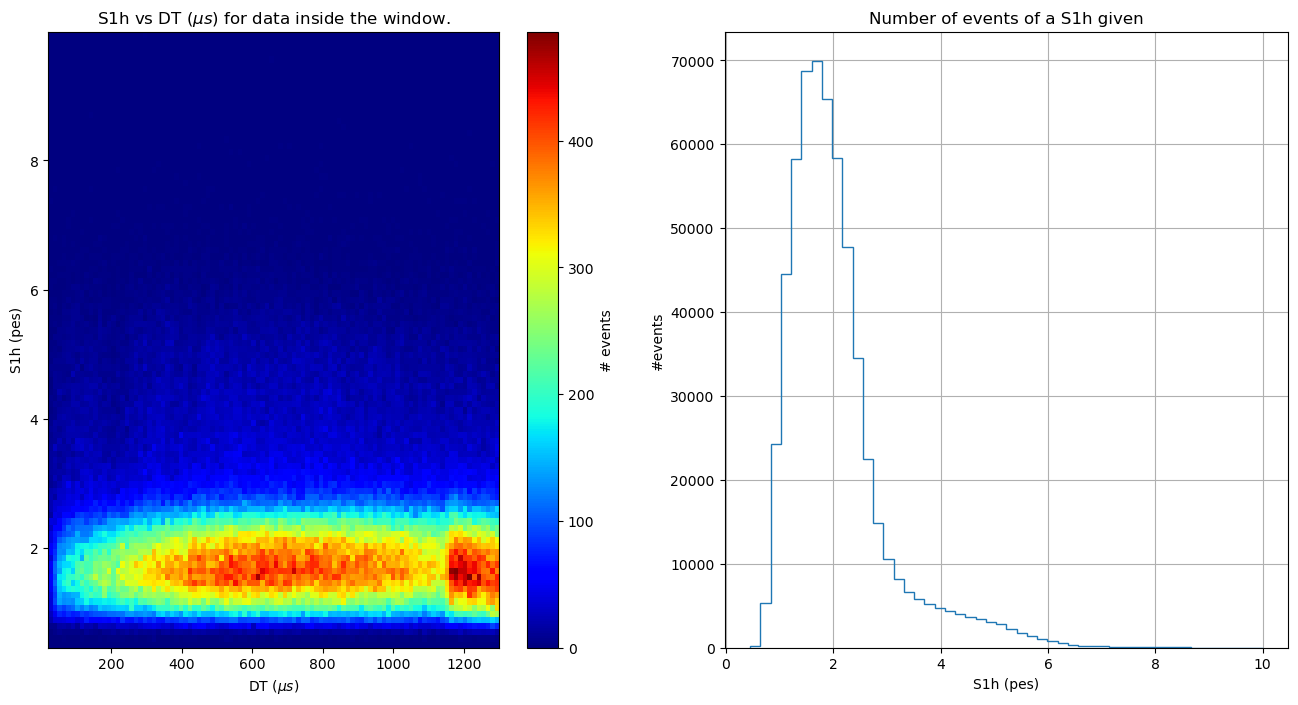

In [159]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))  
hist = ax[0].hist2d(dst_in.DT, dst_in.S1h, bins=100, cmap='jet')
ax[0].set_ylabel(r'S1h (pes)')
ax[0].set_xlabel(r'DT $(\mu s)$')
ax[0].set_title(r'S1h vs DT $(\mu s)$ for data inside the window.')
cbar = plt.colorbar(hist[3], ax=ax[0]) 
cbar.set_label(r'# events')

hist2=ax[1].hist(dst_in.S1h, bins=50, histtype='step')
ax[1].set_ylabel(r'#events')
ax[1].set_xlabel(r'S1h (pes)')
ax[1].grid(True)
ax[1].set_title('Number of events of a S1h given')

### 2. S1e vs DT

Text(0.5, 1.0, 'Number of events of a S1e given')

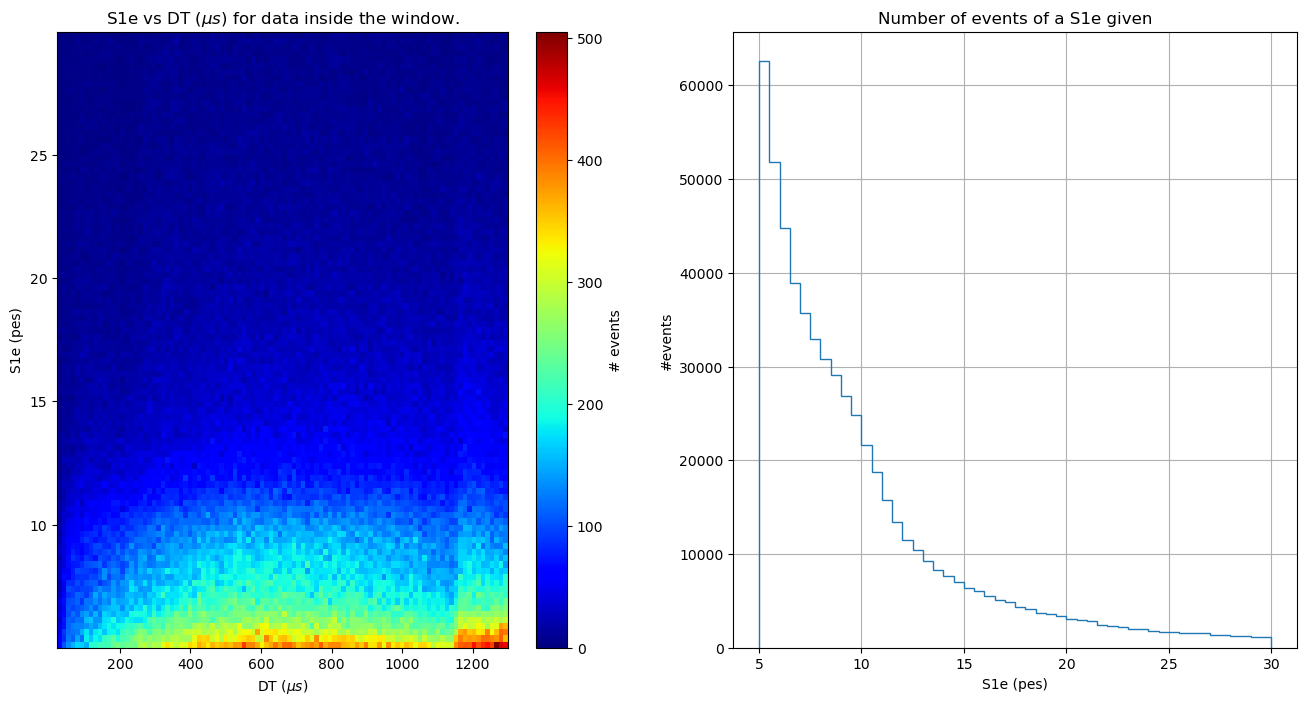

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))  
hist = ax[0].hist2d(dst_in.DT, dst_in.S1e, bins=100, cmap='jet')
ax[0].set_ylabel(r'S1e (pes)')
ax[0].set_xlabel(r'DT $(\mu s)$')
ax[0].set_title(r'S1e vs DT $(\mu s)$ for data inside the window.')
cbar = plt.colorbar(hist[3], ax=ax[0]) 
cbar.set_label(r'# events')

hist2=ax[1].hist(dst_in.S1e, bins=50, histtype='step')
ax[1].set_ylabel(r'#events')
ax[1].set_xlabel(r'S1e (pes)')
ax[1].grid(True)
ax[1].set_title('Number of events of a S1e given')

### 3. S1w vs DT

Text(0.5, 1.0, 'Number of events of a S1w given')

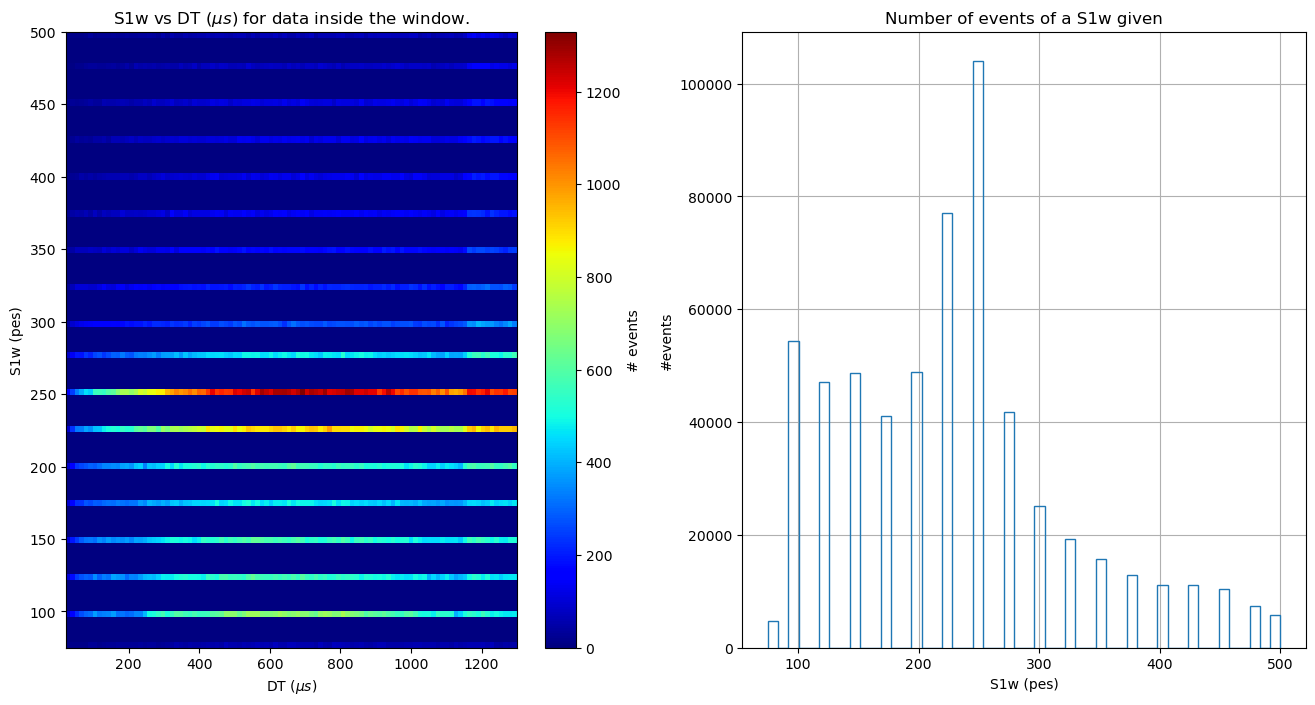

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))  
hist = ax[0].hist2d(dst_in.DT, dst_in.S1w, bins=100, cmap='jet')
ax[0].set_ylabel(r'S1w (pes)')
ax[0].set_xlabel(r'DT $(\mu s)$')
ax[0].set_title(r'S1w vs DT $(\mu s)$ for data inside the window.')
cbar = plt.colorbar(hist[3], ax=ax[0]) 
cbar.set_label(r'# events')

hist2=ax[1].hist(dst_in.S1w, bins=50, histtype='step')
ax[1].set_ylabel(r'#events')
ax[1].set_xlabel(r'S1w (pes)')
ax[1].grid(True)
ax[1].set_title('Number of events of a S1w given')

### S1 vs DT outside the window.

Impongo lo mismo pero esta tiene que estar fuera del corte

### 1. S1h vs DT

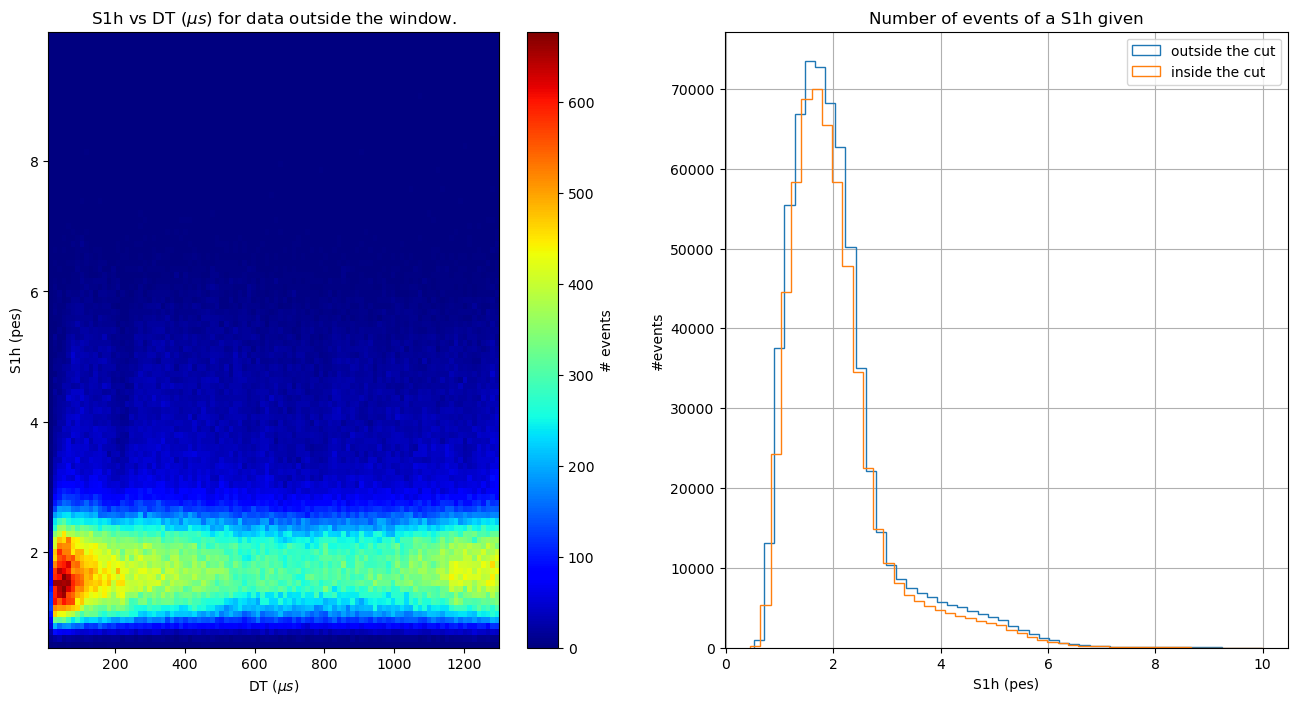

In [166]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))  
hist = ax[0].hist2d(dst_out.DT, dst_out.S1h, bins=100, cmap='jet')
ax[0].set_ylabel(r'S1h (pes)')
ax[0].set_xlabel(r'DT $(\mu s)$')
ax[0].set_title(r'S1h vs DT $(\mu s)$ for data outside the window.')
cbar = plt.colorbar(hist[3], ax=ax[0]) 
cbar.set_label(r'# events')

hist2_out=ax[1].hist(dst_out.S1h, bins=50, histtype='step', label='outside the cut')
ax[1].set_ylabel(r'#events')
ax[1].set_xlabel(r'S1h (pes)')
ax[1].grid(True)
ax[1].set_title('Number of events of a S1h given')

hist2_in=ax[1].hist(dst_in.S1h, bins=50, histtype='step',label='inside the cut')
ax[1].legend()

Misma distribución y misma anchura, hay muchos más eventos a bajo DT pero es esperable porque la mayor parte de los eventos de bajo DT quedan fuera del corte

In [172]:
ratio_height=max(hist2_out[0])/max(hist2_in[0])
print(f'The ratio of the maximum energy of S1 outside/inside the window is: {ratio_height}')

The ratio of the maximum energy of S1 outside/inside the window is: 1.0508658782479372


### 2. S1e vs DT

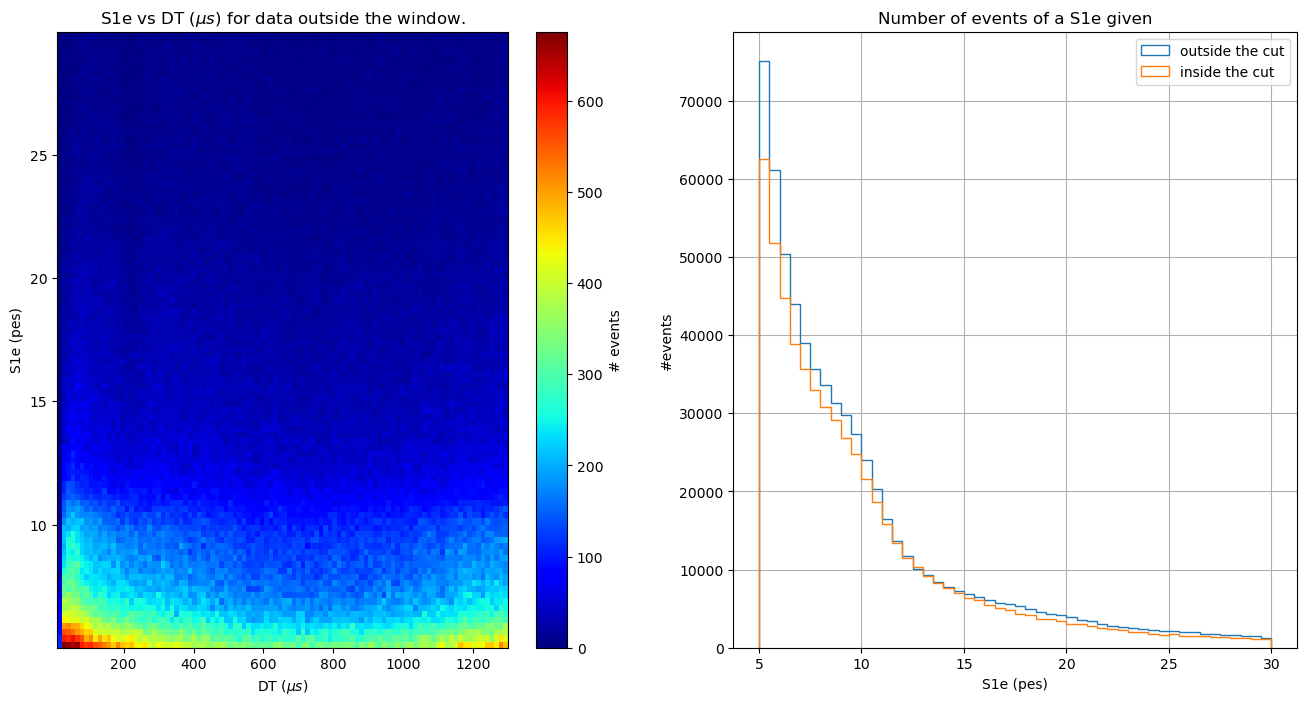

In [176]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))  
hist = ax[0].hist2d(dst_out.DT, dst_out.S1e, bins=100, cmap='jet')
ax[0].set_ylabel(r'S1e (pes)')
ax[0].set_xlabel(r'DT $(\mu s)$')
ax[0].set_title(r'S1e vs DT $(\mu s)$ for data outside the window.')
cbar = plt.colorbar(hist[3], ax=ax[0]) 
cbar.set_label(r'# events')

hist2_out=ax[1].hist(dst_out.S1e, bins=50, histtype='step', label='outside the cut')
ax[1].set_ylabel(r'#events')
ax[1].set_xlabel(r'S1e (pes)')
ax[1].grid(True)
ax[1].set_title('Number of events of a S1e given')

hist2_in=ax[1].hist(dst_in.S1e, bins=50, histtype='step',label='inside the cut')
ax[1].legend()

La misma idea que antes, la energía que se mide cambia de la misma forma que para el caso anterior y las diferencias que se ven en el colormap se deben a que la mayor parte de los eventos que consideramos en este caso están a bajo DT

In [179]:
ratio_energy=hist2_out[0][0]/hist2_in[0][0]
print(f'The ratio of the maximum energy of S1 outside/inside the window is: {ratio_energy}')

The ratio of the maximum energy of S1 outside/inside the window is: 1.1998817740286298


### S1w vs DT

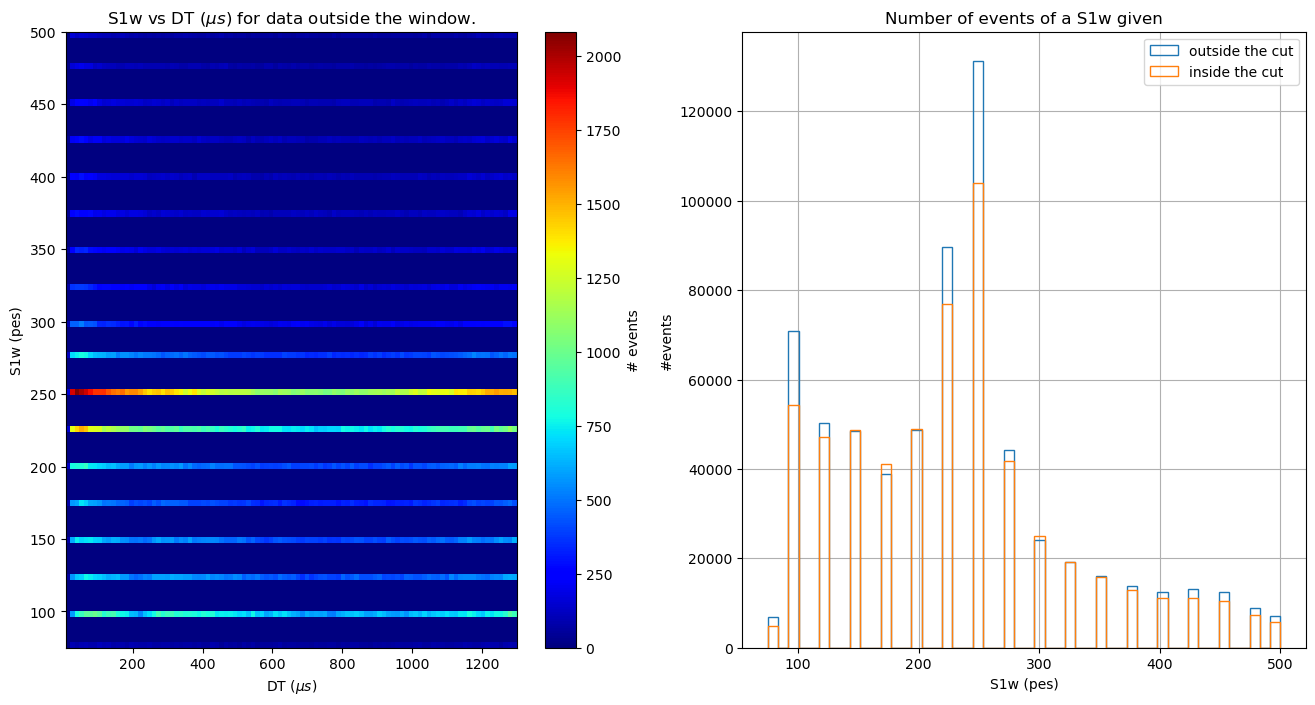

In [181]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))  
hist = ax[0].hist2d(dst_out.DT, dst_out.S1w, bins=100, cmap='jet')
ax[0].set_ylabel(r'S1w (pes)')
ax[0].set_xlabel(r'DT $(\mu s)$')
ax[0].set_title(r'S1w vs DT $(\mu s)$ for data outside the window.')
cbar = plt.colorbar(hist[3], ax=ax[0]) 
cbar.set_label(r'# events')

hist2_out=ax[1].hist(dst_out.S1w, bins=50, histtype='step', label='outside the cut')
ax[1].set_ylabel(r'#events')
ax[1].set_xlabel(r'S1w (pes)')
ax[1].grid(True)
ax[1].set_title('Number of events of a S1w given')

hist2_in=ax[1].hist(dst_in.S1w, bins=50, histtype='step',label='inside the cut')
ax[1].legend()

In [183]:
ratio_width=max(hist2_out[0])/max(hist2_in[0])
print(f'The ratio of the maximum energy of S1 outside/inside the window is: {ratio_width}')

The ratio of the maximum energy of S1 outside/inside the window is: 1.2620464838979546
